# CV Project

## Preprocessing

In [ ]:
%matplotlib tk

In [1]:
from PIL import Image

from matplotlib.widgets import Slider, Button

import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import math

Scanning image resolutions... this might take a minute.


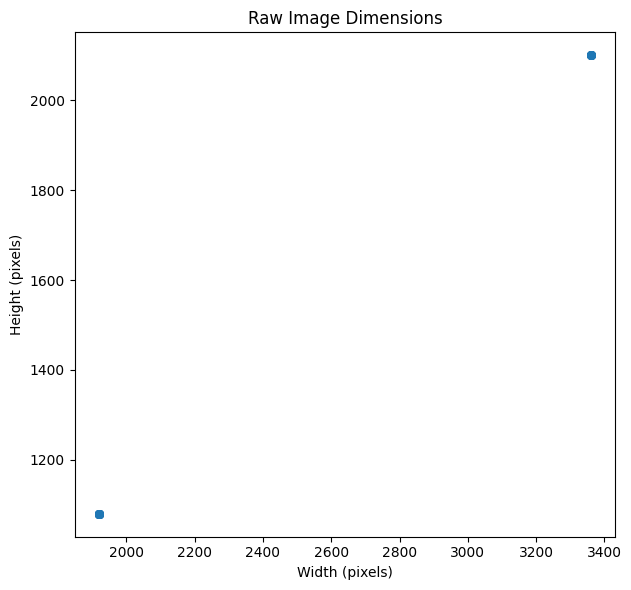

In [2]:
image_dir = Path("./development_set")
data = []

print("Scanning image resolutions... this might take a minute.")
   
for img_path in image_dir.rglob('*.jpg'):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            data.append({
                "Width": width,
                "Height": height
            })
    except Exception as e:
        pass

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Width", y="Height", alpha=0.5, edgecolor=None)
plt.title("Raw Image Dimensions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

In [2]:
HEIGHT = 1920 
WIDTH = 1080

input_dir = Path("./development_set")
output_dir = Path("./processed_images")

In [15]:
def process_and_save_image(file_path, out_path):
    img = cv2.imread(str(file_path))
    
    if img is None:
        print(f"Warning: Could not read {file_path}")
        return

    img_resized = cv2.resize(img, dsize=(HEIGHT, WIDTH)) 

    img_normalized = cv2.normalize(
        img_resized, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U
    )

    cv2.imwrite(str(out_path), img_normalized)

In [16]:
for img_path in input_dir.rglob('*.jpg'):
    rel_path = img_path.relative_to(input_dir)
    out_path = output_dir / rel_path
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    process_and_save_image(img_path, out_path)

print(f"Done! All images processed and saved to {output_dir}")

Done! All images processed and saved to processed_images


# Ball Detection

* Color Masking
* Contour Filtering

In [3]:
img_path = os.path.join(output_dir, '4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg')
img = cv2.imread(img_path)


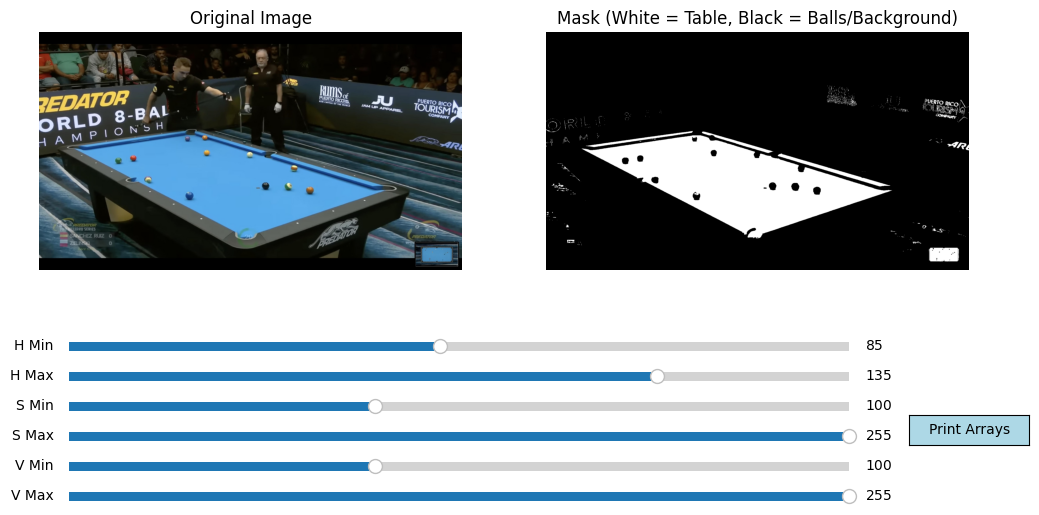

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

fig, (ax_orig, ax_mask) = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(bottom=0.4)

ax_orig.imshow(img_rgb)
ax_orig.set_title("Original Image")
ax_orig.axis('off')

lower_blue = np.array([85, 100, 100])
upper_blue = np.array([135, 255, 255])
mask = cv2.inRange(hsv, lower_blue, upper_blue)
mask_img = ax_mask.imshow(mask, cmap='gray', vmin=0, vmax=255)
ax_mask.set_title("Mask (White = Table, Black = Balls/Background)")
ax_mask.axis('off')

axcolor = 'lightgoldenrodyellow'
ax_hmin = plt.axes([0.15, 0.30, 0.65, 0.03], facecolor=axcolor)
ax_hmax = plt.axes([0.15, 0.25, 0.65, 0.03], facecolor=axcolor)
ax_smin = plt.axes([0.15, 0.20, 0.65, 0.03], facecolor=axcolor)
ax_smax = plt.axes([0.15, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_vmin = plt.axes([0.15, 0.10, 0.65, 0.03], facecolor=axcolor)
ax_vmax = plt.axes([0.15, 0.05, 0.65, 0.03], facecolor=axcolor)

s_hmin = Slider(ax_hmin, 'H Min', 0, 179, valinit=85, valstep=1)
s_hmax = Slider(ax_hmax, 'H Max', 0, 179, valinit=135, valstep=1)
s_smin = Slider(ax_smin, 'S Min', 0, 255, valinit=100, valstep=1)
s_smax = Slider(ax_smax, 'S Max', 0, 255, valinit=255, valstep=1)
s_vmin = Slider(ax_vmin, 'V Min', 0, 255, valinit=100, valstep=1)
s_vmax = Slider(ax_vmax, 'V Max', 0, 255, valinit=255, valstep=1)

def update(val):
    lower = np.array([s_hmin.val, s_smin.val, s_vmin.val])
    upper = np.array([s_hmax.val, s_smax.val, s_vmax.val])
    
    new_mask = cv2.inRange(hsv, lower, upper)
    
    mask_img.set_data(new_mask)
    fig.canvas.draw_idle()

s_hmin.on_changed(update)
s_hmax.on_changed(update)
s_smin.on_changed(update)
s_smax.on_changed(update)
s_vmin.on_changed(update)
s_vmax.on_changed(update)

ax_btn = plt.axes([0.85, 0.15, 0.1, 0.05])
btn = Button(ax_btn, 'Print Arrays', color='lightblue', hovercolor='0.975')

def print_vals(event):
    print("\n--- Copy these into your main script ---")
    print(f"lower_blue = np.array([{int(s_hmin.val)}, {int(s_smin.val)}, {int(s_vmin.val)}])")
    print(f"upper_blue = np.array([{int(s_hmax.val)}, {int(s_smax.val)}, {int(s_vmax.val)}])")
    print("----------------------------------------\n")


btn.on_clicked(print_vals)

plt.show()

Detected 9 validated balls.


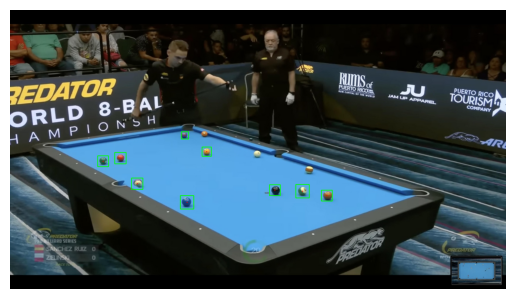

In [48]:
img_path = os.path.join(output_dir, '4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg')
frame = cv2.imread(img_path)
output_frame = frame.copy()

hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
lower_blue = np.array([100, 40, 160])
upper_blue = np.array([135, 255, 255])
# get blue mask for the table
blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# finding contours so we are only looking at table and not surroundings
contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
table_contour = max(contours, key=cv2.contourArea)

table_surface = np.zeros_like(blue_mask)
cv2.drawContours(table_surface, [table_contour], -1, 255, -1)

kernel = np.ones((17, 17), np.uint8)
table_surface = cv2.erode(table_surface, kernel, iterations=1)

#grey mapping of the table
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
gray_table = cv2.bitwise_and(gray, gray, mask=table_surface)
gray_blur = cv2.medianBlur(gray_table, 5)

circles = cv2.HoughCircles(
    gray_blur, 
    cv2.HOUGH_GRADIENT, 
    dp=1.1, 
    minDist=16,       
    param1=80,        # Highly sensitive to soft edges
    param2=15,        # Will detect shadows and ghosts
    minRadius=8,      # Allow smaller balls for different camera heights
    maxRadius=25      # Allow larger balls
)


# A list to store our final, verified balls
valid_balls = []

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    
    for (x, y, r) in circles:
        # VERIFICATION A: The Color Test
        circle_mask = np.zeros_like(blue_mask)
        cv2.circle(circle_mask, (x, y), int(r * 0.8), 255, -1) 
        mean_blue_val = cv2.mean(blue_mask, mask=circle_mask)[0]
        
        if mean_blue_val < 120:  
            
            # --- GHOST FIX 2: PREVENT OVERLAPPING (NMS) ---
            is_duplicate = False
            for (vx, vy, vr) in valid_balls:
                # Calculate the distance between this new circle and already validated ones
                distance = math.sqrt((x - vx)**2 + (y - vy)**2)
                if distance < 18: # If centers are within 18 pixels, it's the same ball!
                    is_duplicate = True
                    break
            
            # If it passed the color test AND isn't a duplicate, save it!
            if not is_duplicate:
                valid_balls.append((x, y, r))

# 5. Draw the Final Validated Balls
img_height, img_width = frame.shape[:2]

for (x, y, r) in valid_balls:
    # Safe Bounding Box Calculation
    padding = int(r * 0.30) + 3
    adjusted_r = r + padding
    
    top_left_x = max(0, x - adjusted_r)
    top_left_y = max(0, y - adjusted_r)
    bottom_right_x = min(img_width, x + adjusted_r)
    bottom_right_y = min(img_height, y + adjusted_r)
    
    cv2.rectangle(output_frame, (top_left_x, top_left_y), (bottom_right_x, bottom_right_y), (0, 255, 0), 2)
    cv2.circle(output_frame, (x, y), 2, (0, 0, 255), -1)

print(f"Detected {len(valid_balls)} validated balls.")

plt.imshow(cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

In [6]:
from billard_detector import detect_billiard_balls, run_on_directory
from pathlib import Path
import os
import cv2

In [ ]:
run_on_directory(Path("./processed_images"))

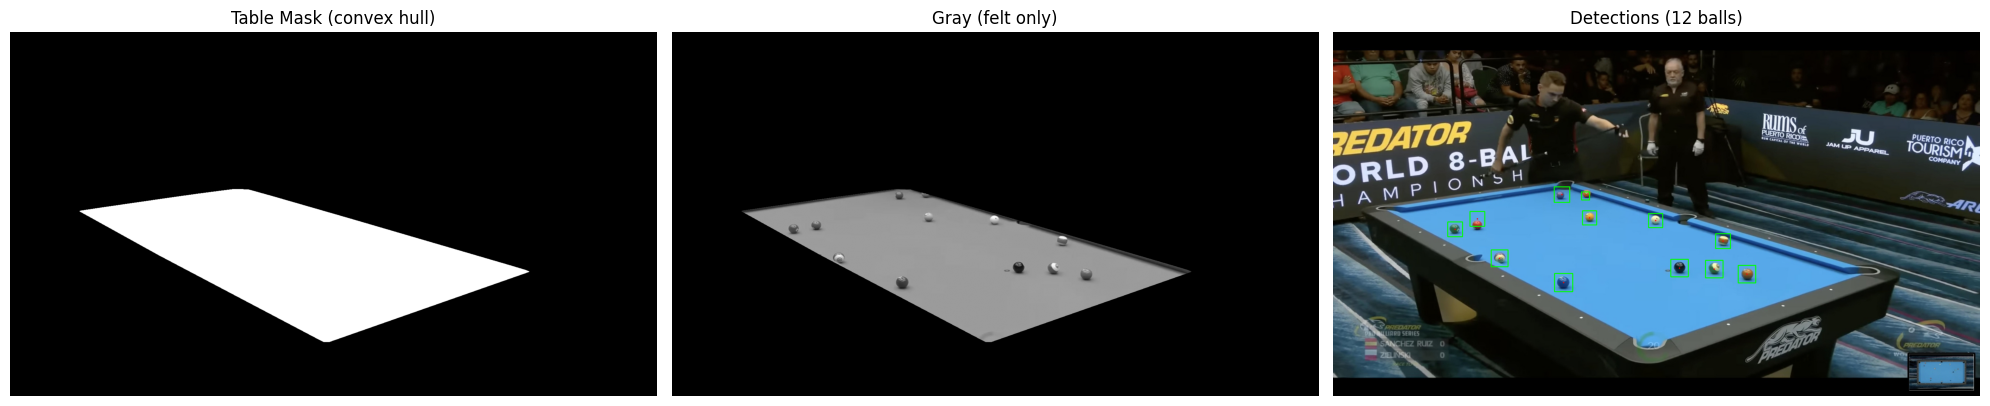

In [2]:
output_dir = Path("./processed_images")
img_path = os.path.join(output_dir, '4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)

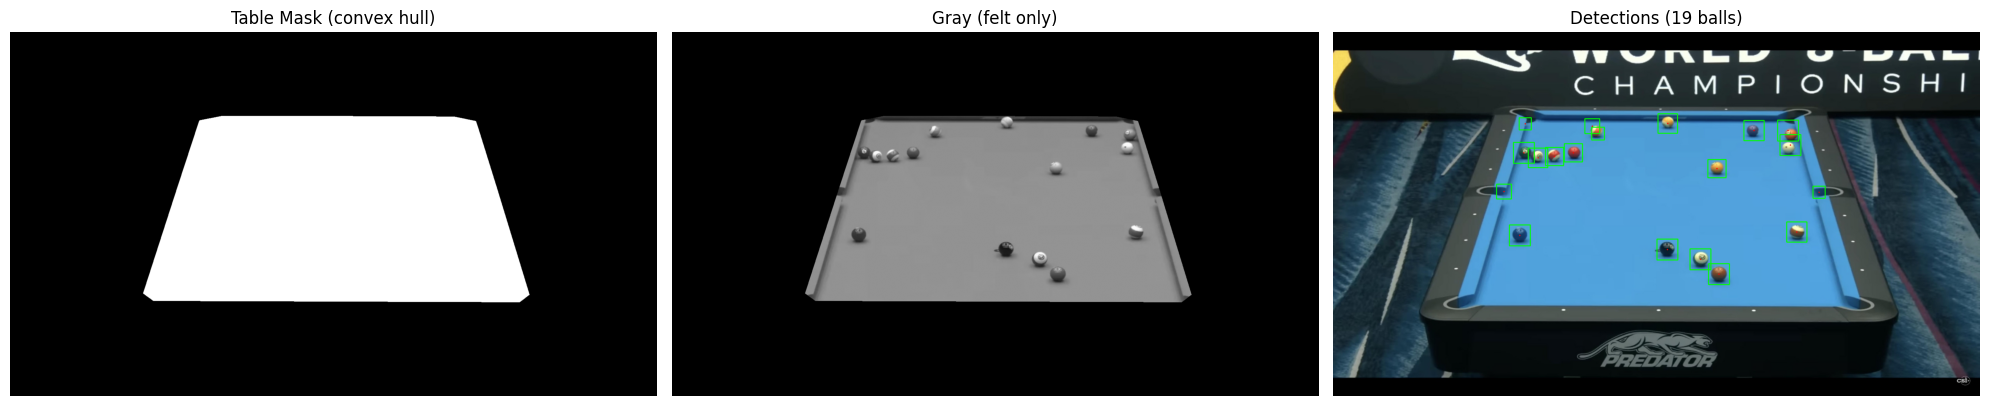

In [3]:
img_path = os.path.join(output_dir, '3f_png.rf.81c7e132365ef95bb19380ca389025f6.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)

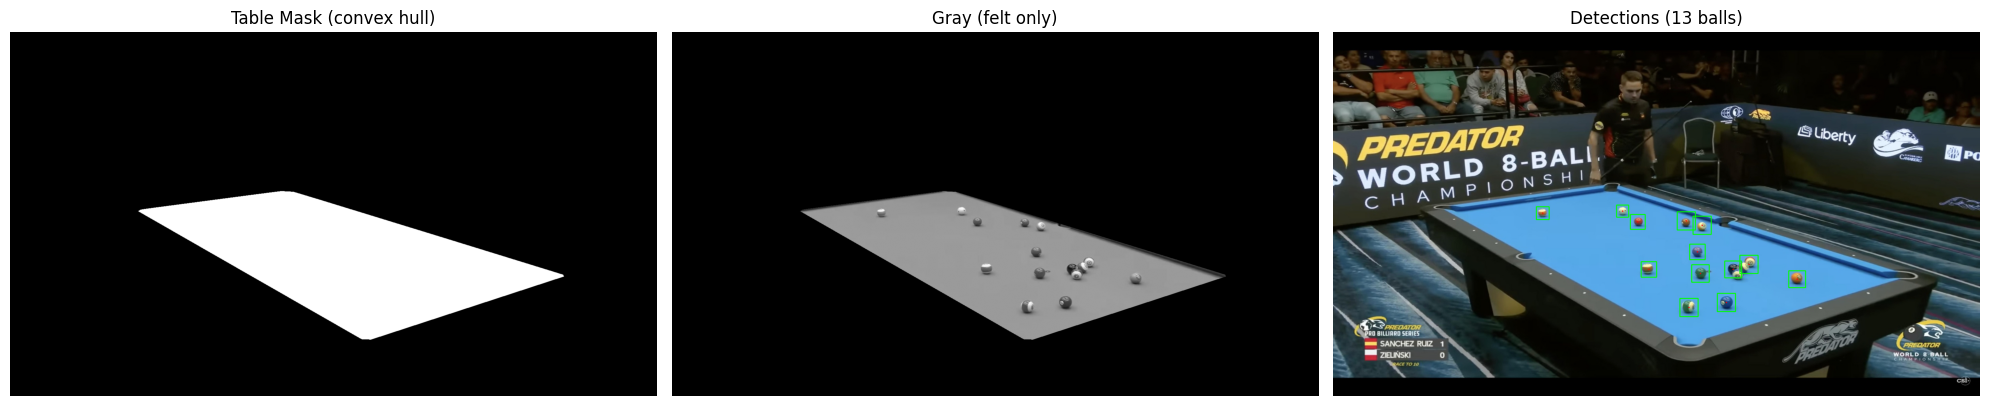

In [4]:
img_path = os.path.join(output_dir, '5a_png.rf.bae1d48b3d2d96a990799b836ecebcbb.jpg')
frame = cv2.imread(img_path)
output_frame, balls = detect_billiard_balls(frame, debug=True)